In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("/content/Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


Duplicates

In [3]:
print(f'Number of duplicates in this dataset: {df.duplicated().sum()}')

Number of duplicates in this dataset: 0


In [3]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


#DATA CLEANING

Missing values

In [4]:
for i in df:
    if df[i].isnull().sum()>0:
        print(f'{i} has: {df[i].isnull().sum()} missing values')

Weather has: 30 missing values
Traffic_Level has: 30 missing values
Time_of_Day has: 30 missing values
Courier_Experience_yrs has: 30 missing values


In [5]:
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])
df['Traffic_Level'] = df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0])
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])

df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [6]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


#EDA

##Distribution

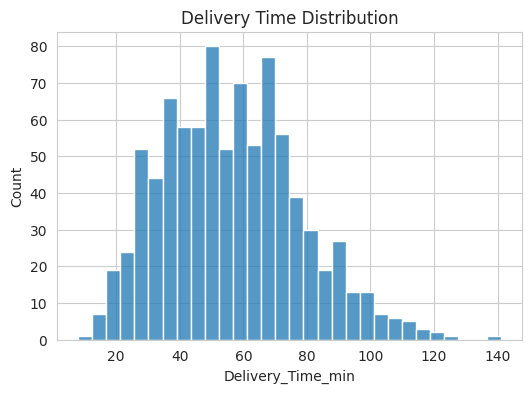

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(df["Delivery_Time_min"], bins=30)
plt.title("Delivery Time Distribution")
plt.show()

##Distance vs Delivery Time

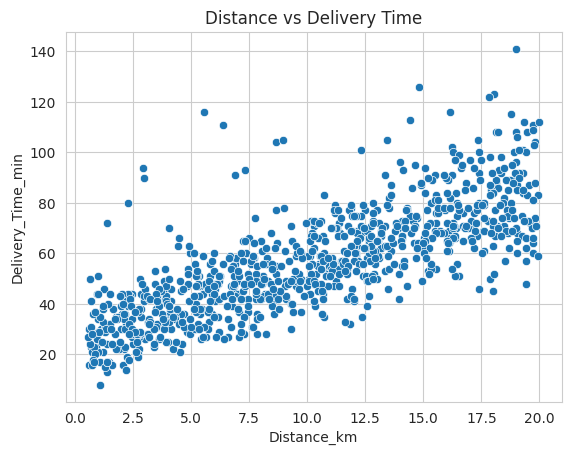

In [6]:
sns.scatterplot(x="Distance_km", y="Delivery_Time_min", data=df)
plt.title("Distance vs Delivery Time")
plt.show()

##Traffic Impact

/tmp/ipykernel_590/702929469.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Traffic_Level")["Delivery_Time_min"].mean().plot(kind="bar")


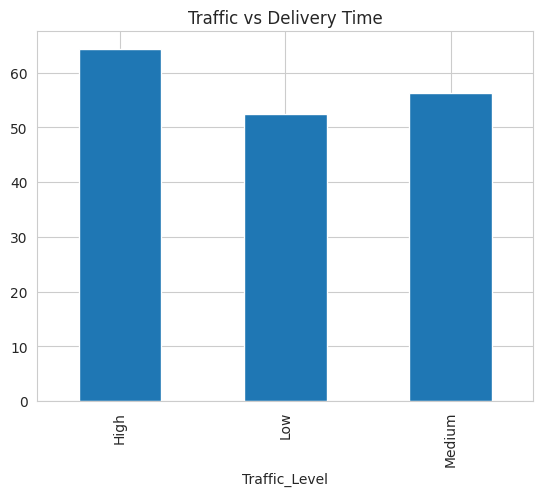

In [7]:
df.groupby("Traffic_Level")["Delivery_Time_min"].mean().plot(kind="bar")
plt.title("Traffic vs Delivery Time")
plt.show()

##Time of Day

/tmp/ipykernel_590/292696915.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Time_of_Day")["Delivery_Time_min"].mean().plot(kind="bar")


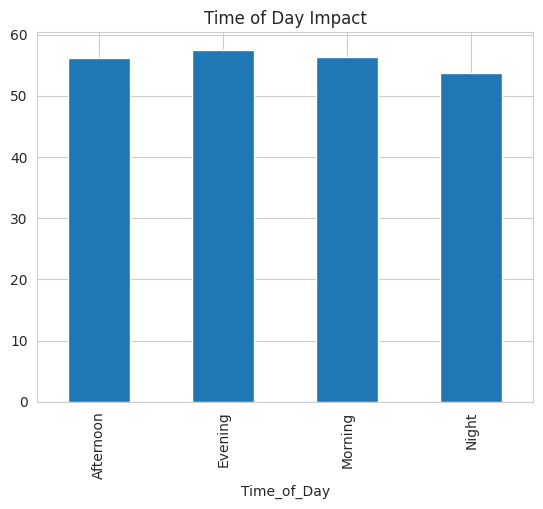

In [8]:
df.groupby("Time_of_Day")["Delivery_Time_min"].mean().plot(kind="bar")
plt.title("Time of Day Impact")
plt.show()

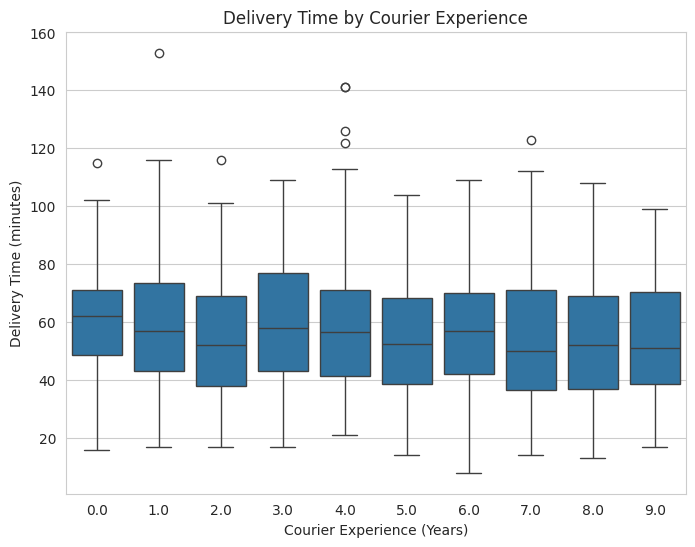

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Courier_Experience_yrs', y='Delivery_Time_min', data=df)
plt.title("Delivery Time by Courier Experience")
plt.xlabel("Courier Experience (Years)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

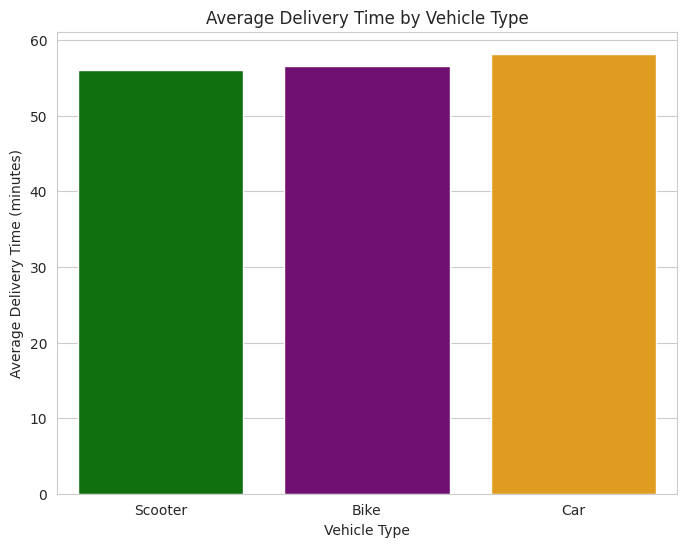

In [8]:
plt.figure(figsize=(8, 6))
sns.barplot(x='Vehicle_Type', y='Delivery_Time_min', data=df, errorbar=None, hue='Vehicle_Type', palette = {'Scooter': "green", 'Bike': "purple", 'Car': 'orange'})
plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (minutes)")
plt.show()

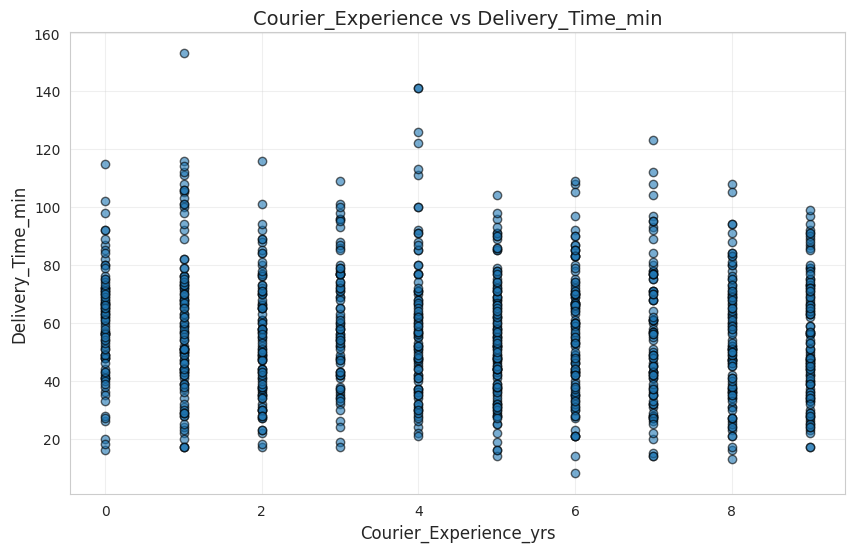

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Courier_Experience_yrs"], df["Delivery_Time_min"], alpha=0.6, edgecolor='k')
plt.title("Courier_Experience vs Delivery_Time_min", fontsize=14)
plt.xlabel("Courier_Experience_yrs", fontsize=12)
plt.ylabel("Delivery_Time_min", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

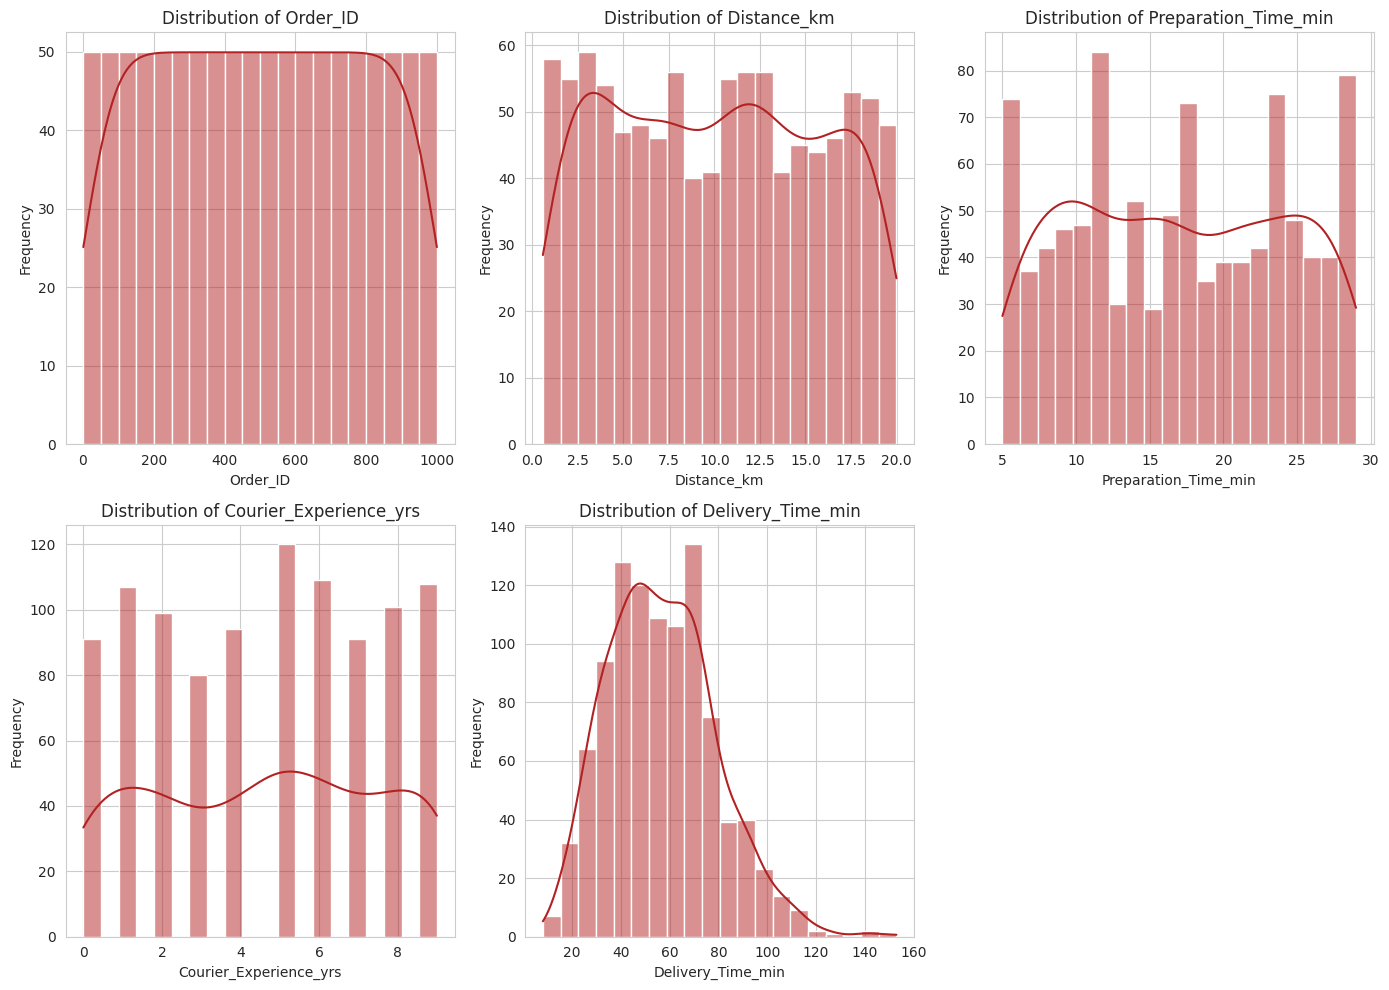

In [10]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols) // 3 + 1, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color='firebrick')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#Emissions

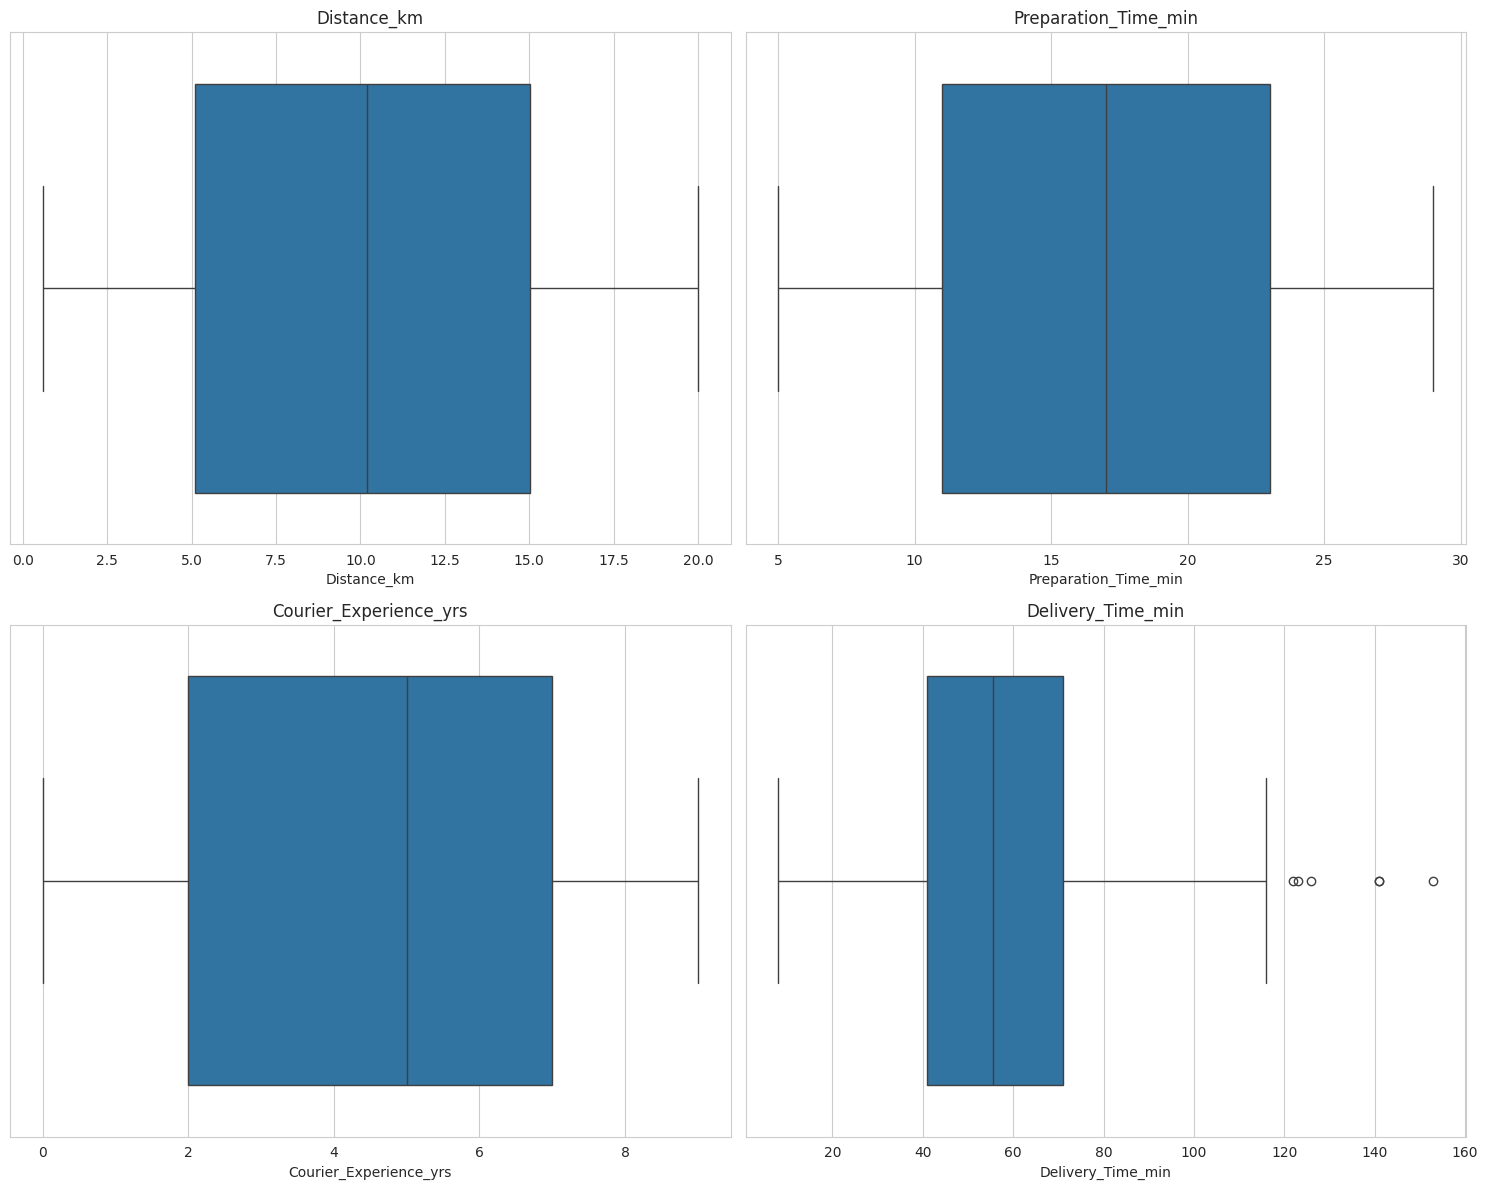

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.boxplot(x=df['Distance_km'], ax=axes[0, 0])
axes[0, 0].set_title('Distance_km')

sns.boxplot(x=df['Preparation_Time_min'], ax=axes[0, 1])
axes[0, 1].set_title('Preparation_Time_min')

sns.boxplot(x=df['Courier_Experience_yrs'], ax=axes[1, 0])
axes[1, 0].set_title('Courier_Experience_yrs')

sns.boxplot(x=df['Delivery_Time_min'], ax=axes[1, 1])
axes[1, 1].set_title('Delivery_Time_min')

plt.tight_layout()
plt.show()

                        Order_ID  Distance_km  Preparation_Time_min  \
Order_ID                1.000000    -0.023792             -0.035362   
Distance_km            -0.023792     1.000000             -0.009025   
Preparation_Time_min   -0.035362    -0.009025              1.000000   
Courier_Experience_yrs  0.012912    -0.005951             -0.031124   
Delivery_Time_min      -0.033831     0.816535              0.305535   

                        Courier_Experience_yrs  Delivery_Time_min  
Order_ID                              0.012912          -0.033831  
Distance_km                          -0.005951           0.816535  
Preparation_Time_min                 -0.031124           0.305535  
Courier_Experience_yrs                1.000000          -0.085540  
Delivery_Time_min                    -0.085540           1.000000  


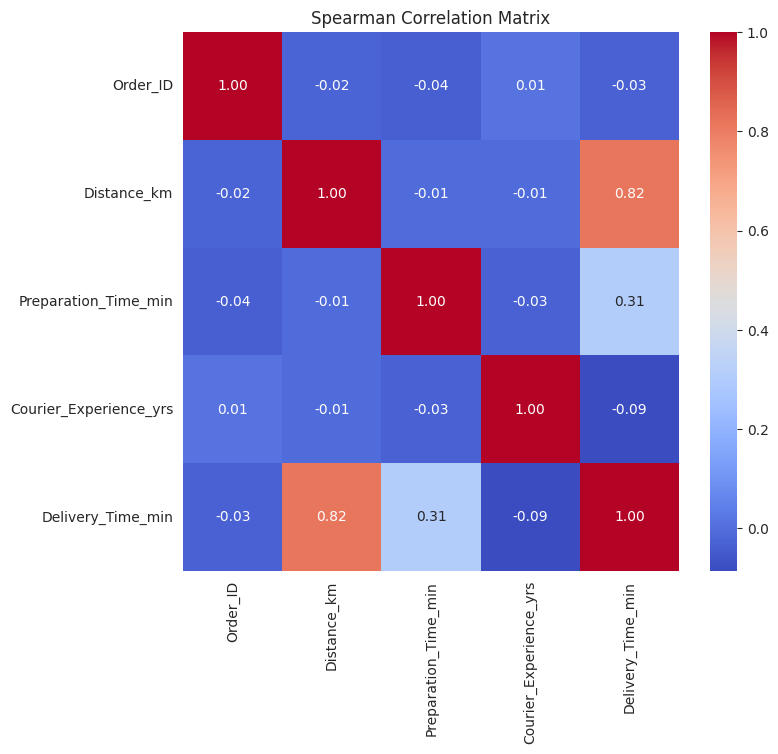

In [12]:
numeric_df = df.select_dtypes(include=['number'])
spearman_corr = numeric_df.corr(method='spearman')

# Выводим матрицу корреляции
print(spearman_corr)

# Построение тепловой карты для визуализации матрицы корреляции
plt.figure(figsize=(8, 7))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Spearman Correlation Matrix')
plt.show()

#SQL ANALYSIS

In [9]:
import sqlite3

conn = sqlite3.connect(":memory:")
df.to_sql("orders", conn, index=False)

883

Avg delivery time per traffic

In [10]:
query = """
SELECT Traffic_Level, AVG(Delivery_Time_min) as avg_time
FROM orders
GROUP BY Traffic_Level
"""
pd.read_sql(query, conn)

,Traffic_Level,avg_time
0,High,64.298343
1,Low,52.498559
2,Medium,56.250704


Peak time delays

In [11]:
query = """
SELECT Time_of_Day, AVG(Delivery_Time_min)
FROM orders
GROUP BY Time_of_Day
ORDER BY AVG(Delivery_Time_min) DESC
"""
pd.read_sql(query, conn)

,Time_of_Day,AVG(Delivery_Time_min)
0,Evening,57.509294
1,Morning,56.405694
2,Afternoon,56.108949
3,Night,53.736842


Distance impact

In [12]:
query = """
SELECT
    CASE
        WHEN Distance_km < 5 THEN 'Short'
        WHEN Distance_km < 10 THEN 'Medium'
        ELSE 'Long'
    END as Distance_Category,
    AVG(Delivery_Time_min)
FROM orders
GROUP BY Distance_Category
"""
pd.read_sql(query, conn)

,Distance_Category,AVG(Delivery_Time_min)
0,Long,70.526316
1,Medium,48.507177
2,Short,34.522936


#Preparing data

In [13]:
df = pd.get_dummies(df, columns=['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], drop_first=True)

In [14]:
df.head()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,12,1.0,43,False,False,False,True,True,False,False,False,False,False,True
1,738,16.42,20,2.0,84,False,False,False,False,False,True,True,False,False,False,False
2,741,9.52,28,1.0,59,True,False,False,False,True,False,False,False,True,False,True
3,661,7.44,5,1.0,37,False,True,False,False,False,True,False,False,False,False,True
4,412,19.03,16,5.0,68,False,False,False,False,True,False,False,True,False,False,False


In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from scipy.stats import norm
import matplotlib.pyplot as plt

!pip install catboost
from catboost import CatBoostRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [15]:
df.shape

(1000, 16)

In [18]:
X = df.drop(['Order_ID', 'Delivery_Time_min'], axis = 1)
y = df['Delivery_Time_min']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=250)

#Machine learning

XGBoost

In [25]:
xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='mae')


param_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.2],
    'max_depth': [3, 5, 10],
    'subsample': [0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

grid_search__xgb = GridSearchCV(xgb_regressor, param_xgb, cv=5)


grid_search__xgb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric='mae',
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=Non...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.1, 0.2], 'max_depth': [3, 5, 10],
                         'min_child_weight': [1, 3, 5],
                         'n_estimators': [50, 100, 200],
                         'subsample': [0.8, 1.0]})

In [26]:
grid_search__xgb.best_params_

{'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 3,
 'n_estimators': 50,
 'subsample': 0.8}

In [27]:
best_gs_xgb_two = grid_search__xgb.best_estimator_

In [28]:
y_test_pred1 = best_gs_xgb_two.predict(X_test)
mae_test = mean_absolute_error(y_test, y_test_pred1)

print('Score on train data = ', round(best_gs_xgb_two.score(X_train, y_train), 4))
print('Score on test data = ', round(best_gs_xgb_two.score(X_test, y_test), 4))
print('MAE on test data =', round(mae_test, 4))

Score on train data =  0.8036
Score on test data =  0.8003
MAE on test data = 6.7233


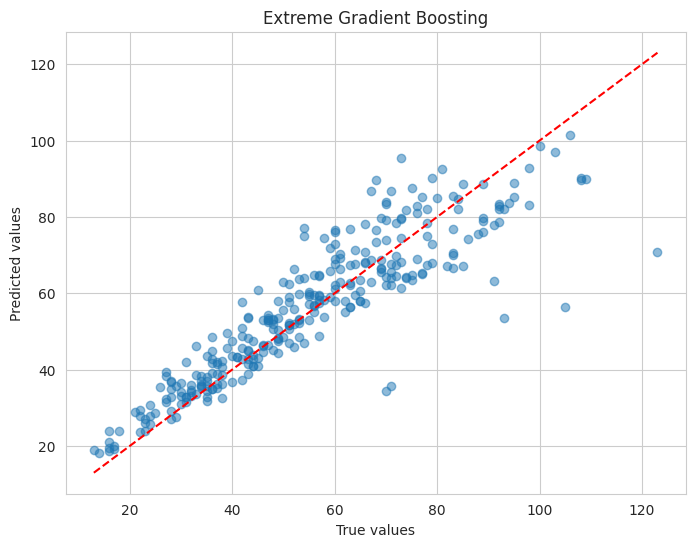

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred1, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('Extreme Gradient Boosting')
plt.show()

##LightGBM

In [31]:
gb_regressor = lgb.LGBMRegressor(objective='regression', metric='mae', verbose=-1)

param_lgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 10],
    'num_leaves': [31, 50, 100],
    'subsample': [0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

grid_search_lgb = GridSearchCV(gb_regressor, param_lgb, cv=5, scoring='neg_mean_absolute_error')

grid_search_lgb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=LGBMRegressor(metric='mae', objective='regression',
                                     verbose=-1),
             param_grid={'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [3, 5, 10], 'min_child_weight': [1, 3, 5],
                         'n_estimators': [50, 100, 200],
                         'num_leaves': [31, 50, 100], 'subsample': [0.8, 1.0]},
             scoring='neg_mean_absolute_error')

In [32]:
print('Best params:', grid_search_lgb.best_params_)

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'num_leaves': 31, 'subsample': 0.8}


In [33]:
best_lgb = grid_search_lgb.best_estimator_

In [35]:
y_test_pred2 = best_lgb.predict(X_test)
mae_test = mean_absolute_error(y_test, y_test_pred2)

print('Score on train data:', round(best_lgb.score(X_train, y_train), 4))
print('Score on test data:', round(best_lgb.score(X_test, y_test), 4))
print('MAE on test data:', round(mae_test, 4))

Score on train data: 0.817
Score on test data: 0.792
MAE on test data: 6.7521


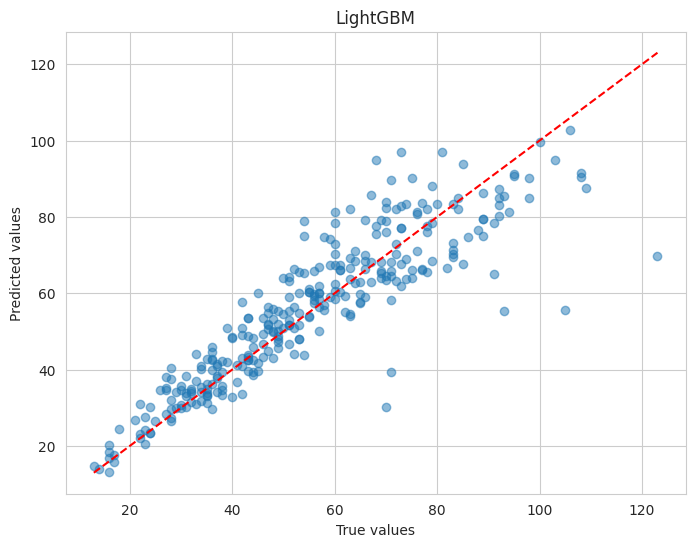

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred2, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title('LightGBM')
plt.show()